In [7]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

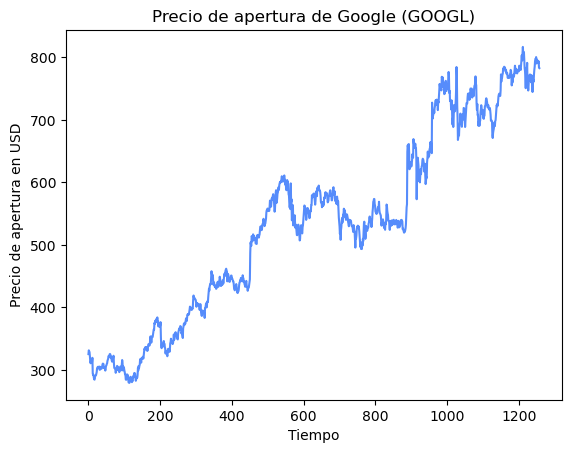

In [2]:
ruta = r"C:\Users\alfre\documentos_ssd\UNAM\Artículos\libro\data\precio_google.csv"

data_train = pd.read_csv(ruta)
data_train.head(10)

data = data_train.loc[:,["Open"]].values
plt.plot(data)
plt.xlabel("Tiempo")
plt.ylabel("Precio de apertura en USD")
plt.title("Precio de apertura de Google (GOOGL)")
plt.show()

In [3]:
## Preprocesando data
# Ajuste de dimensiones
data = data.reshape(-1,1)
data = data.astype("float32")
data.shape

# Rescalamiento
scaler = MinMaxScaler(feature_range=(0,1))
data = scaler.fit_transform(data)

# Conjunto de entrenamiento y conjunto de pruebas
train_size = int(len(data) * 0.8)
test_size = len(data) - train_size
train = data[0:train_size, :]
test = data[train_size:len(data), :]
print("train size: {}, test size: {} ".format(len(train), len(test)))

# Bloques de tiempo (5 observaciones)
timesteps = 5
x_data = []
y_data = []

for i in range(len(train) - timesteps -1):
    a = train[i:(i+timesteps), 0]
    x_data.append(a)
    y_data.append(train[i + timesteps, 0])
x_train = np.array(x_data)
y_train = np.array(y_data)

x_data = []
y_data = []
for i in range(len(test) - timesteps -1):
    a = test[i:(i+timesteps), 0]
    x_data.append(a)
    y_data.append(test[i + timesteps, 0])

x_test = np.array(x_data)
y_test = np.array(y_data)
x_train = np.reshape(x_train, (x_train.shape[0], 1, x_train.shape[1]))
x_test = np.reshape(x_test, (x_test.shape[0], 1 , x_test.shape[1]))


train size: 1006, test size: 252 


In [4]:
## Modelo LSTM
model = Sequential()
model.add(LSTM(100, input_shape = (1, timesteps)))
model.add(Dense(units=1))
model.compile(loss = "mean_squared_error", optimizer= "adam")
model.fit(x_train, y_train, epochs = 100, batch_size = 1)


Epoch 1/100


C:\Users\alfre\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0045
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.2886e-04
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.2484e-04
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.8714e-04
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 4.8198e-04
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.4580e-04
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.0878e-04
Epoch 8/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.1812e-04
Epoch 9/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.2721e-04
Epoch 10/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.7430e-04
Epoch 11/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.7328e-04
Epoch 12/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3.9234e-04
Epoch 13/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3.6307e-04
Epoch 14/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms

In [5]:
# Genera la prediccion del train y del test
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


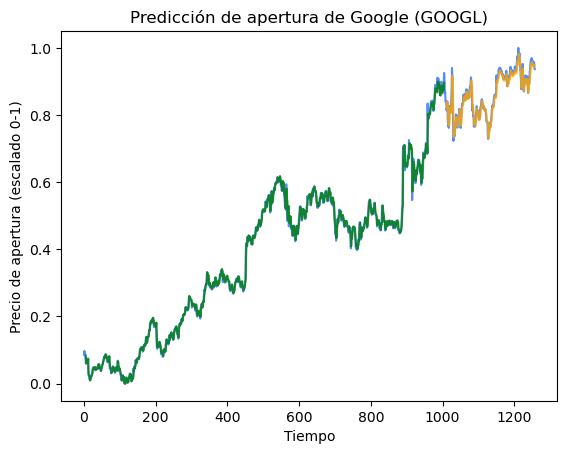

MAPE 0.01696525700390339


In [32]:
# Visualizando el modelo de entrenamiento
# train
train_pred_plot = np.empty_like(data)
train_pred_plot[:,:] = np.nan
train_pred_plot[timesteps:len(train_pred) + timesteps, :] = train_pred

# predicción
test_prep_plot = np.empty_like(data)
test_prep_plot[:,:] = np.nan
test_prep_plot[len(train_pred) + (timesteps * 2) + 1:len(data) -1,:] = test_pred

mape = mean_absolute_percentage_error(y_test, test_pred)
mse = mean_squared_error(y_test, test_pred)

# Gráfica de predicción y entrenamiento
plt.plot(data) #plt.plot(scaler.inverse_transform(data))
plt.plot(train_pred_plot, alpha = 0.8, color = 'green')
plt.plot(test_prep_plot, alpha = 0.8, color = 'orange')
plt.xlabel("Tiempo")
plt.ylabel("Precio de apertura (escalado 0-1)")
plt.title("Predicción de apertura de Google (GOOGL)")
plt.show()

print('MAPE', mape)

In [31]:
1- mape

0.9830347429960966